# Example 20: Nonlinear Site Response — Low vs High Intensity

This example compares three analysis methods at two shaking intensities:

| Method | Abbrev | Description |
|--------|--------|-------------|
| Equivalent Linear | EQL | Frequency-domain, strain-compatible modulus/damping |
| Time-Domain MKZ | TD-MKZ | Nonlinear TD with Modified Kondner-Zelasko model |
| Time-Domain HH | TD-HH | Nonlinear TD with Hybrid Hyperbolic model |

Two intensity levels are used:
- **Low**: PGA = 0.01 g → nearly linear, all methods should agree
- **High**: PGA = 0.50 g → strongly nonlinear, methods diverge

The time-domain workflow uses `prepare()` to fit constitutive model parameters,
which can be inspected with `plot_fit()` before running the analysis.

In [1]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np

import pystrata

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## 1. Load and Scale Input Motion

We use the recorded NIS090 accelerogram (Northridge 1994) as the base motion and
scale it linearly to two target PGA levels by multiplying by a constant factor.
This preserves the frequency content and waveform shape between runs.


In [2]:
MOTION_FILE = "data/NIS090.AT2"

# Load the recorded motion once to get its natural PGA
_base = pystrata.motion.TimeSeriesMotion.load_at2_file(MOTION_FILE)
_base_pga = _base.pga  # natural PGA in g

TARGET_LOW = 0.01  # g
TARGET_HIGH = 0.50  # g

motion_low = pystrata.motion.TimeSeriesMotion.load_at2_file(
    MOTION_FILE, scale=TARGET_LOW / _base_pga
)
motion_high = pystrata.motion.TimeSeriesMotion.load_at2_file(
    MOTION_FILE, scale=TARGET_HIGH / _base_pga
)

print(f"Record      : {_base.description}")
print(f"Natural PGA : {_base_pga:.4f} g")
print(f"Low  scale  : {TARGET_LOW / _base_pga:.4f}  →  PGA = {motion_low.pga:.4f} g")
print(f"High scale  : {TARGET_HIGH / _base_pga:.4f}  →  PGA = {motion_high.pga:.4f} g")

Record      : KOBE 01/16/95 2046, NISHI-AKASHI, 090 (CUE)
Natural PGA : 0.5027 g
Low  scale  : 0.0199  →  PGA = 0.0100 g
High scale  : 0.9945  →  PGA = 0.5000 g


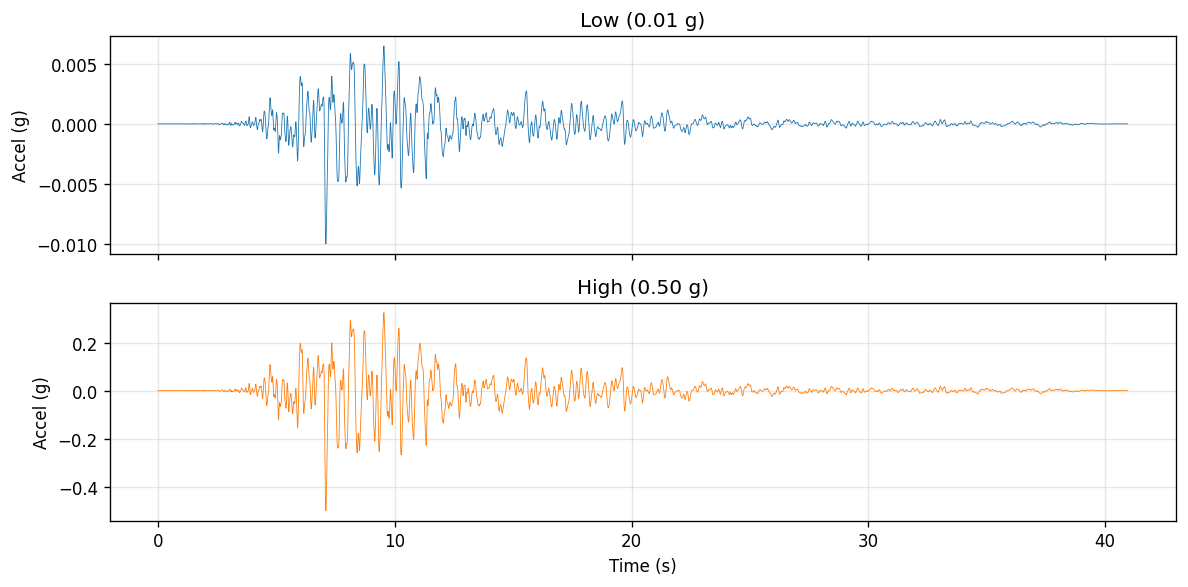

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(motion_low.times, motion_low.accels, lw=0.5)
axes[1].plot(motion_high.times, motion_high.accels, lw=0.5, color="C1")
for ax, lbl in zip(axes, ["Low (0.01 g)", "High (0.50 g)"]):
    ax.set_ylabel("Accel (g)")
    ax.set_title(lbl)
    ax.grid(True, alpha=0.3)
axes[1].set_xlabel("Time (s)")
fig.tight_layout()

## 2. Create Site Profile

Three-layer profile with Darendeli nonlinear curves:

| Layer | Thickness (m) | Vs (m/s) | PI | Stress (kPa) |
|-------|--------------|----------|----|--------------|
| 1 | 10 | 200 | 20 | 50 |
| 2 | 10 | 350 | 15 | 150 |
| HS | — | 700 | — | — |

Text(0.5, 1.0, 'Vs Profile (auto-discretized)')

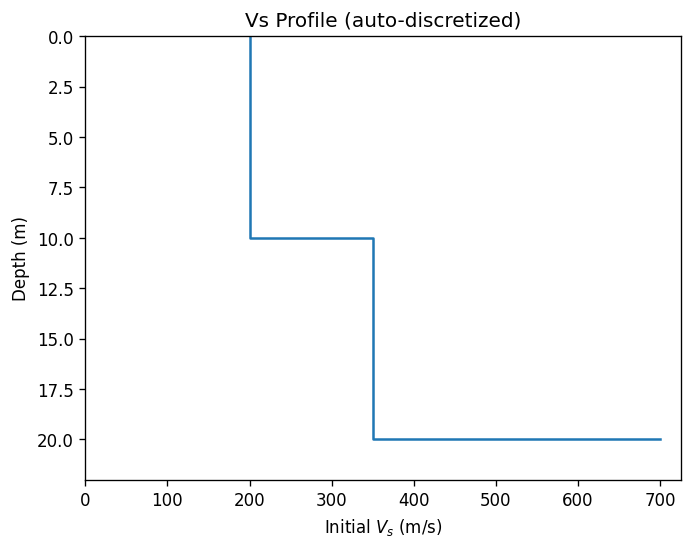

In [4]:
profile = pystrata.site.Profile(
    [
        pystrata.site.Layer(
            pystrata.site.DarendeliSoilType(
                unit_wt=18.0, plas_index=20, ocr=1.0, stress_mean=50
            ),
            thickness=10,
            shear_vel=200,
        ),
        pystrata.site.Layer(
            pystrata.site.DarendeliSoilType(
                unit_wt=19.0, plas_index=15, ocr=1.0, stress_mean=150
            ),
            thickness=10,
            shear_vel=350,
        ),
        pystrata.site.Layer(
            pystrata.site.SoilType("Rock", unit_wt=24.0, mod_reduc=None, damping=0.01),
            thickness=0,
            shear_vel=700,
        ),
    ]
    # Auto-discretize for capturing strains within all modeling approaches (EQL, FDM, and time-domain)
).auto_discretize(max_freq=50, wave_frac=0.2)


ax = profile.plot("initial_shear_vel")
ax.set_title("Vs Profile (auto-discretized)")

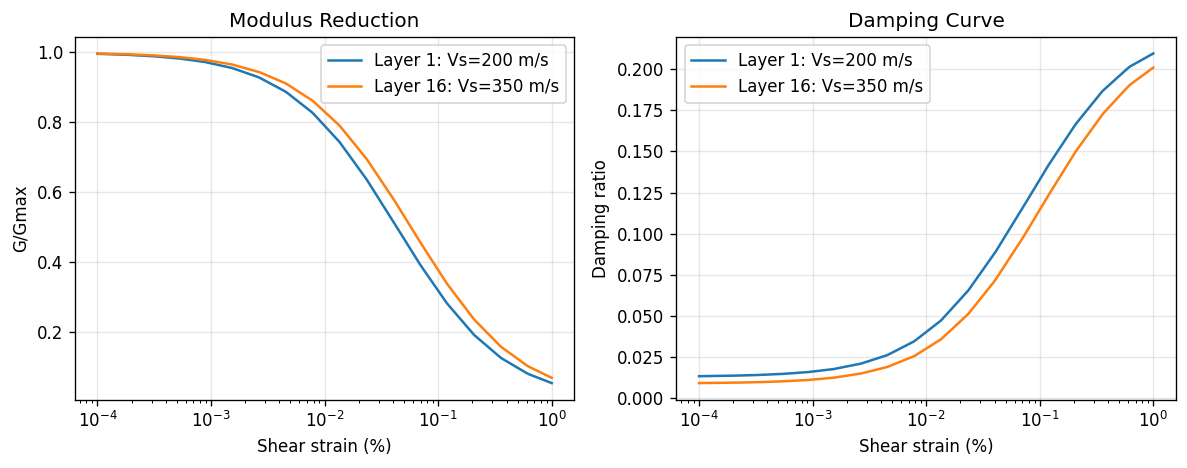

In [5]:
# Plot nonlinear curves for each soil layer
strains_pct = np.logspace(-4, 0, 200)  # % units
strains_dec = strains_pct / 100  # decimal units (as expected by the curves)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ["C0", "C1"]
for i, layer in enumerate([0, 15]):
    st = profile.layers[layer].soil_type
    label = f"Layer {layer + 1}: Vs={profile.layers[layer].initial_shear_vel:.0f} m/s"
    axes[0].semilogx(
        strains_pct, st.mod_reduc(strains_dec), color=colors[i], label=label
    )
    axes[1].semilogx(strains_pct, st.damping(strains_dec), color=colors[i], label=label)

axes[0].set(xlabel="Shear strain (%)", ylabel="G/Gmax", title="Modulus Reduction")
axes[1].set(xlabel="Shear strain (%)", ylabel="Damping ratio", title="Damping Curve")
for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.tight_layout()

## 2b. Prepare Constitutive Models and Inspect Fit

Use `TimeDomainCalculator.prepare()` to fit MKZ and HH parameters to each
soil layer, then inspect the quality of fit with `plot_fit()`.


In [6]:
from pystrata.curve_fitting import plot_fit

# Create calculators and prepare (fit) constitutive models
calc_mkz = pystrata.propagation.TimeDomainCalculator(model="mkz", boundary="elastic")
calc_hh = pystrata.propagation.TimeDomainCalculator(model="hh", boundary="elastic")

params_mkz = calc_mkz.prepare(profile, verbose=True)
params_hh, damp_params_hh = calc_hh.prepare(profile, verbose=True)

Fitting MKZ parameters...
Fitting layer 1/21: depth=0.38m
Fitting layer 2/21: depth=1.15m
Fitting layer 3/21: depth=1.92m
Fitting layer 4/21: depth=2.69m
Fitting layer 5/21: depth=3.46m
Fitting layer 6/21: depth=4.23m
Fitting layer 7/21: depth=5.00m
Fitting layer 8/21: depth=5.77m
Fitting layer 9/21: depth=6.54m
Fitting layer 10/21: depth=7.31m
Fitting layer 11/21: depth=8.08m
Fitting layer 12/21: depth=8.85m
Fitting layer 13/21: depth=9.62m
Fitting layer 14/21: depth=10.63m
Fitting layer 15/21: depth=11.88m
Fitting layer 16/21: depth=13.13m
Fitting layer 17/21: depth=14.38m
Fitting layer 18/21: depth=15.63m
Fitting layer 19/21: depth=16.88m
Fitting layer 20/21: depth=18.12m
Fitting layer 21/21: depth=19.38m
Fitting HH double parameters...
Fitting layer 1/21: depth=0.38m (two-set)
Fitting layer 2/21: depth=1.15m (two-set)
Fitting layer 3/21: depth=1.92m (two-set)
Fitting layer 4/21: depth=2.69m (two-set)
Fitting layer 5/21: depth=3.46m (two-set)
Fitting layer 6/21: depth=4.23m (two-set


--- MKZ fit ---


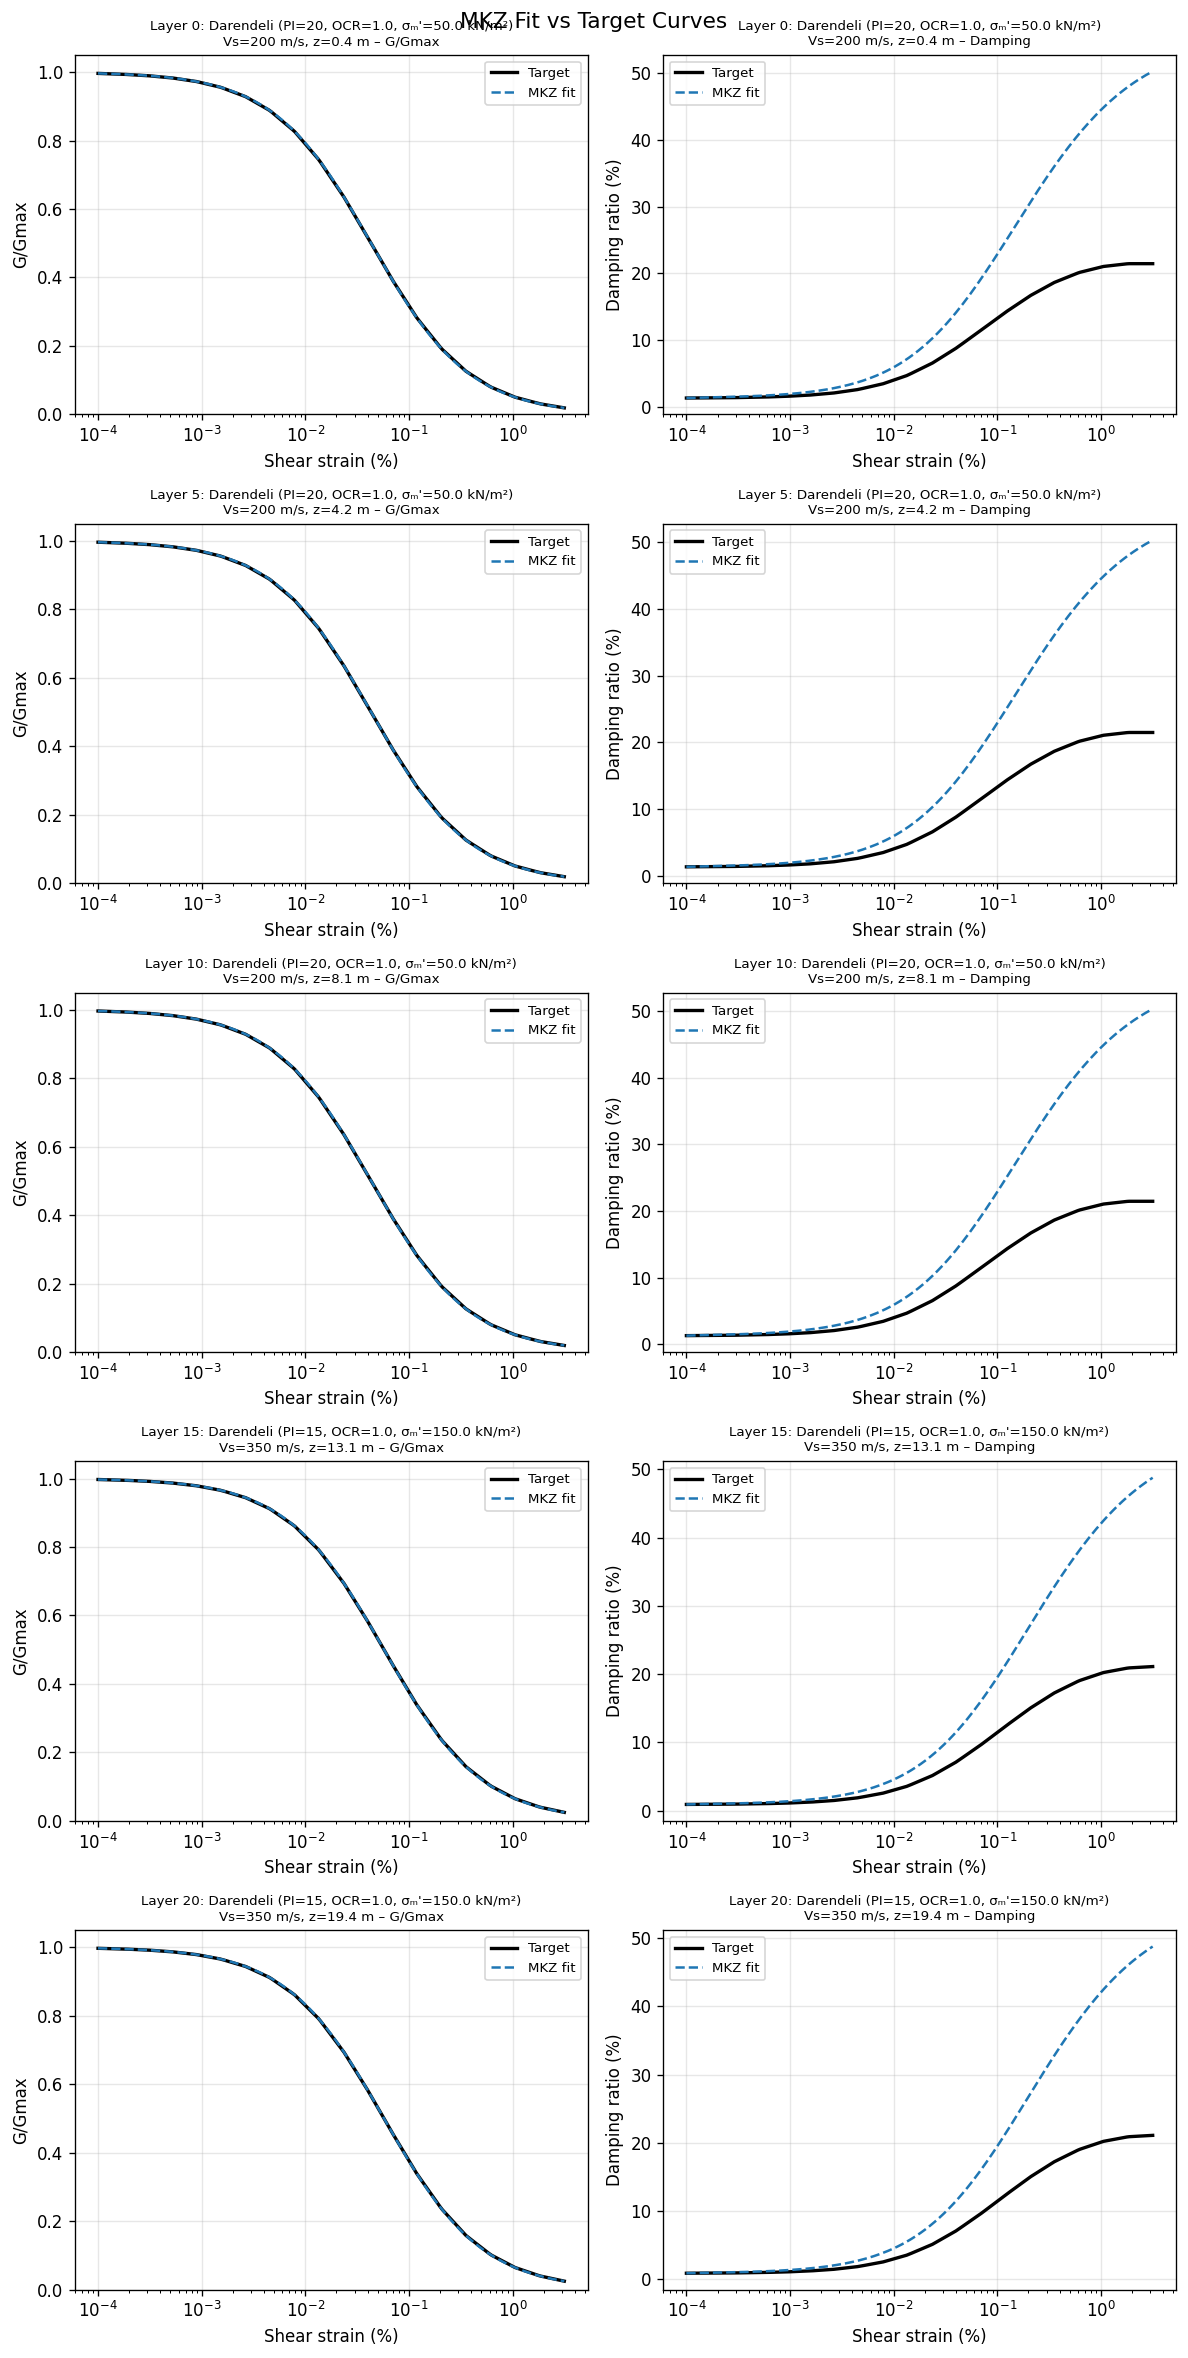


--- HH fit ---


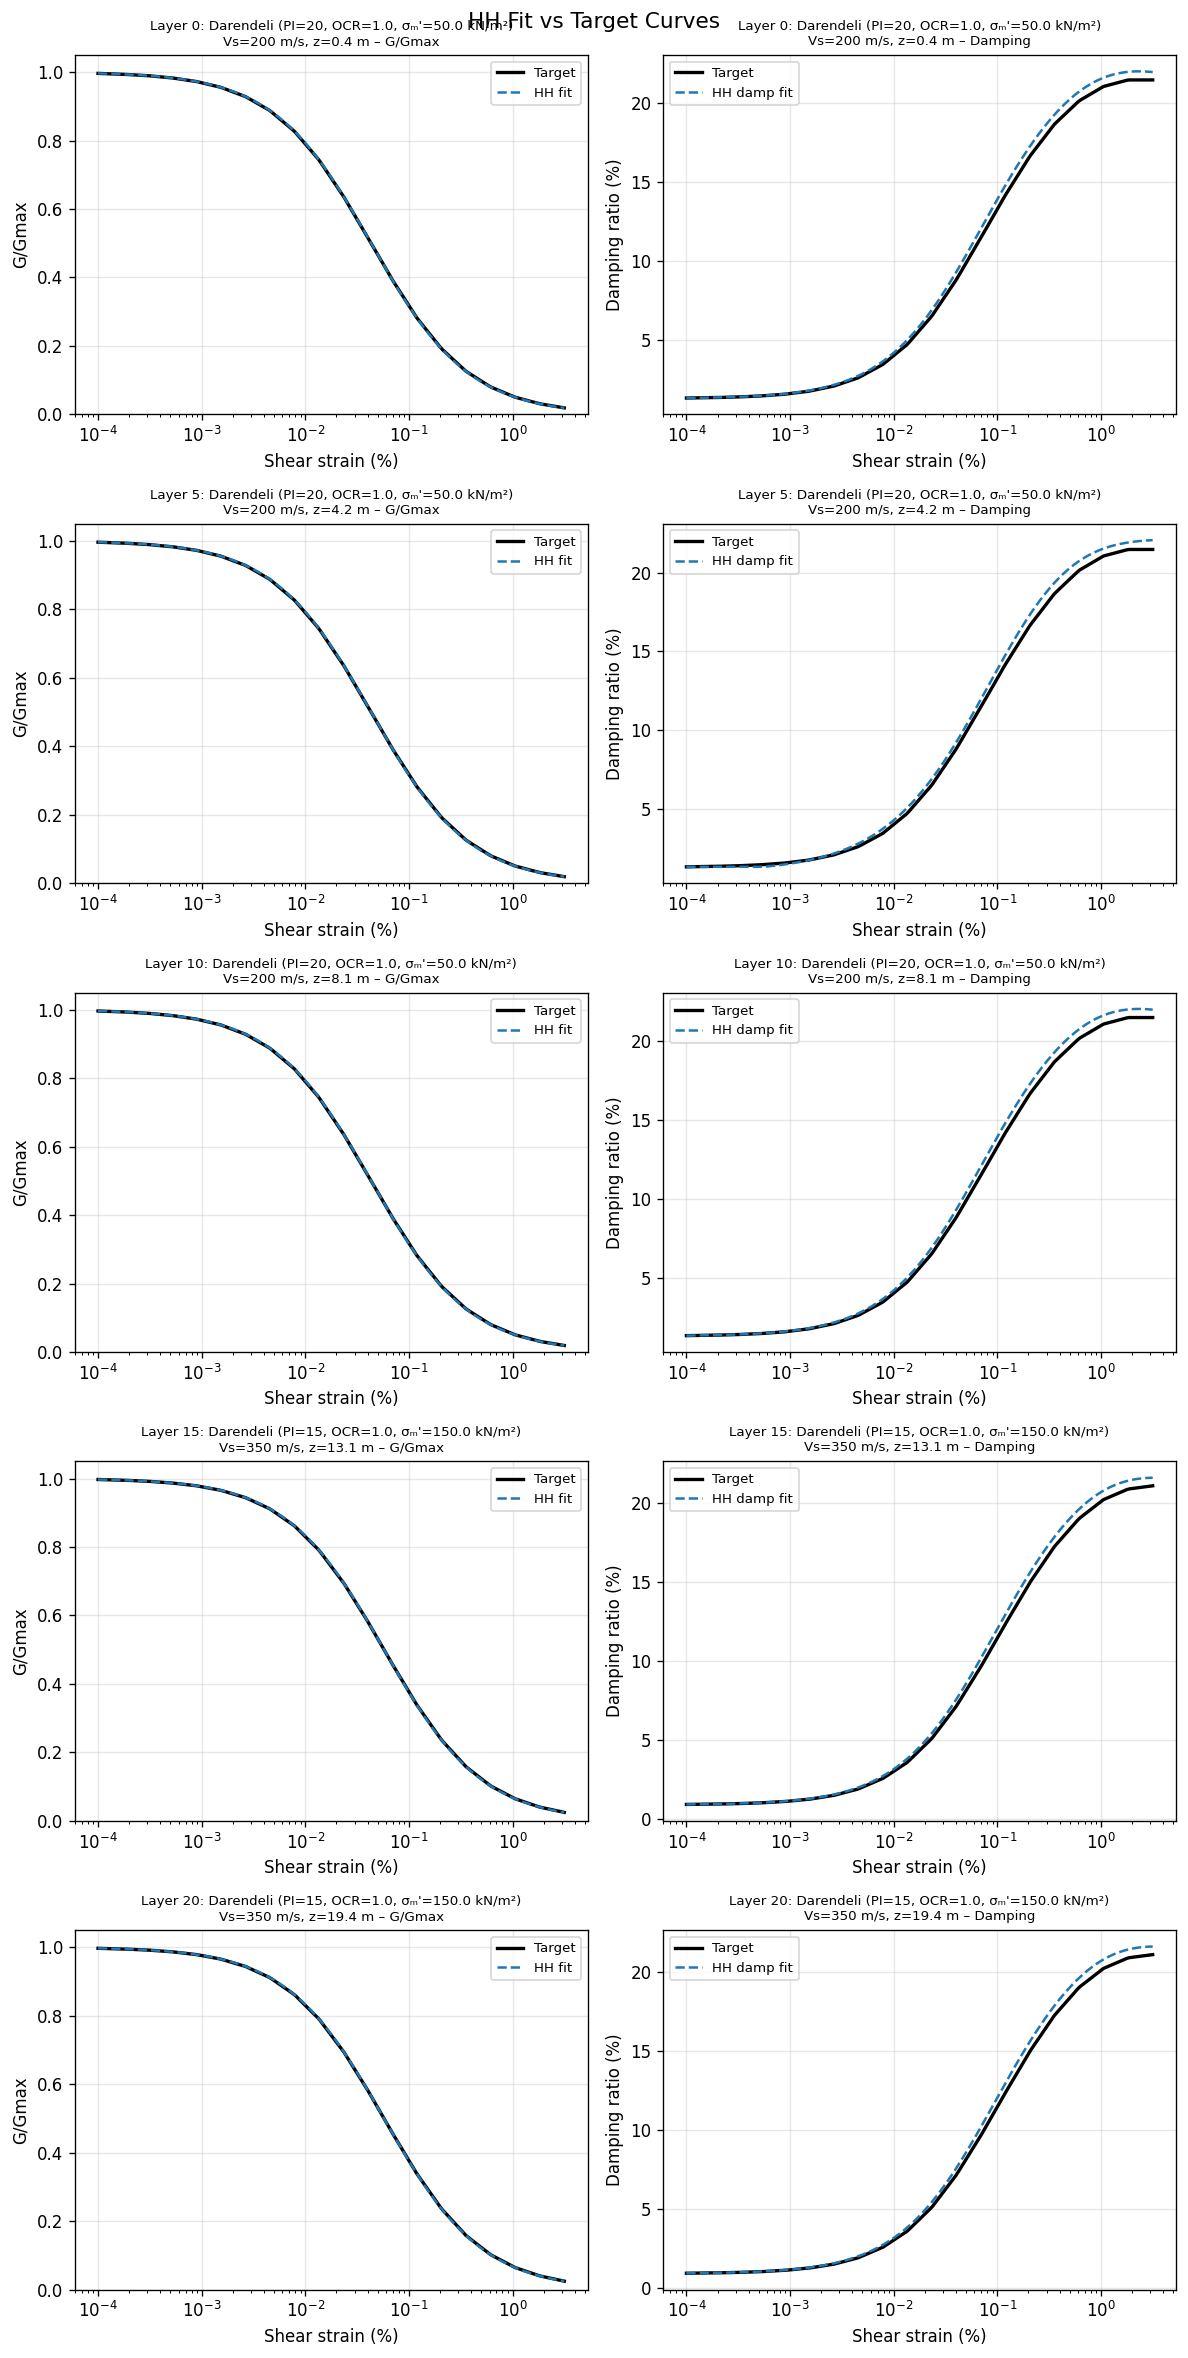

In [7]:
# Inspect MKZ fit (plot unique soil types — use step to skip repeated sub-layers)
print("\n--- MKZ fit ---")
plot_fit(profile, params_mkz, step=5)
plt.suptitle("MKZ Fit vs Target Curves", fontsize=13)
plt.tight_layout()
plt.show()

# Inspect HH fit
print("\n--- HH fit ---")
plot_fit(profile, params_hh, step=5, damp_params=damp_params_hh)
plt.suptitle("HH Fit vs Target Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Set Up Calculators

In [8]:
def make_calcs() -> dict:
    """Create a fresh set of calculators."""
    return {
        "EQL": pystrata.propagation.EquivalentLinearCalculator(strain_ratio=0.65),
        "FDM": pystrata.propagation.FrequencyDependentEqlCalculator(),
        "TD-MKZ": pystrata.propagation.TimeDomainCalculator(
            model="mkz", boundary="elastic"
        ),
        "TD-HH": pystrata.propagation.TimeDomainCalculator(
            model="hh", boundary="elastic"
        ),
    }

## 4. Define Outputs and Run All Analyses

In [9]:
freqs = np.logspace(-1, 2, 300)
loc_surface = pystrata.output.OutputLocation("outcrop", index=0)
loc_input = pystrata.output.OutputLocation("outcrop", index=-1)


def make_outputs():
    return pystrata.output.OutputCollection(
        [
            pystrata.output.ResponseSpectrumOutput(freqs, loc_surface, 0.05),
            pystrata.output.ResponseSpectrumRatioOutput(
                freqs, loc_input, loc_surface, 0.05
            ),
            pystrata.output.MaxStrainProfile(),
        ]
    )

In [10]:
all_calcs = {}  # {(intensity, method): calculator}
all_outputs = {}  # {intensity: OutputCollection}

for label, motion in [("low", motion_low), ("high", motion_high)]:
    calcs = make_calcs()
    outputs = make_outputs()
    print(f"\n--- Intensity: {label} (PGA={motion.pga:.2f} g) ---")

    for name, calc in calcs.items():
        print(f"  Running {name}...", end=" ")
        loc_in = profile.location("outcrop", index=-1)
        calc(motion, profile, loc_in)
        outputs(calc, name)
        print("done")

        all_calcs[(label, name)] = calc

    all_outputs[label] = outputs

print("\nAll analyses complete.")


--- Intensity: low (PGA=0.01 g) ---
  Running EQL... done
  Running FDM... done
  Running TD-MKZ... done
  Running TD-HH... done

--- Intensity: high (PGA=0.50 g) ---
  Running EQL... done
  Running FDM... done
  Running TD-MKZ... done
  Running TD-HH... done

All analyses complete.


## 5. Compare Response Spectra

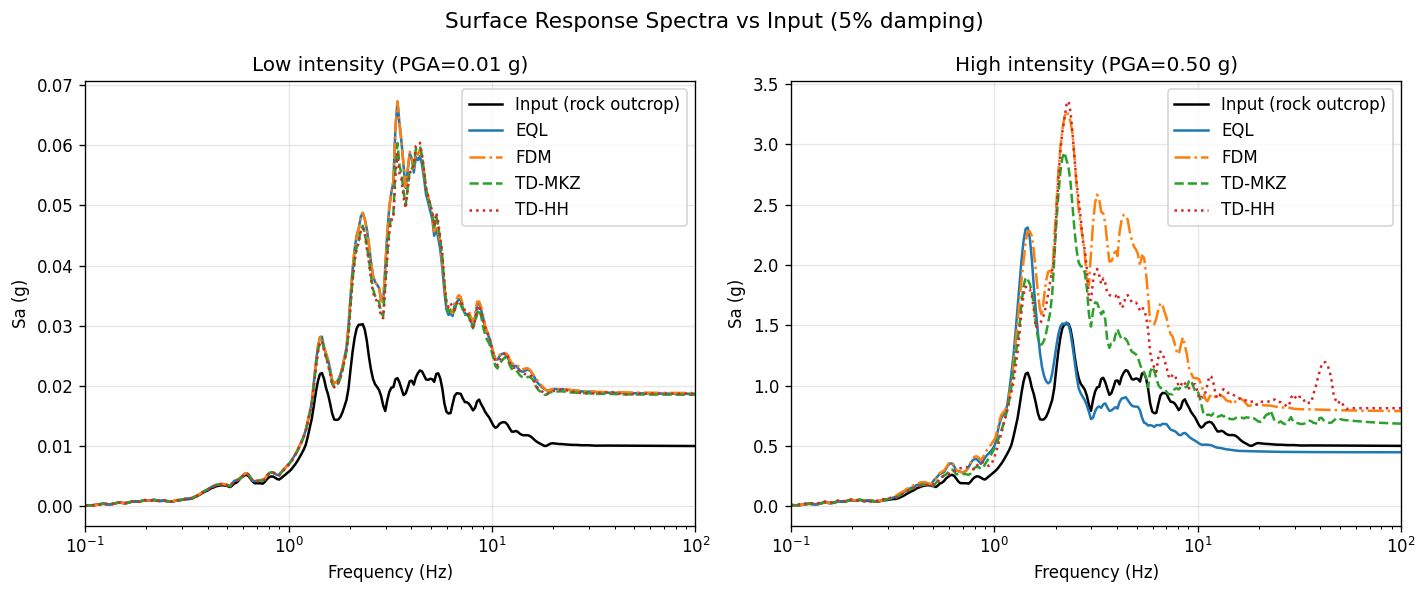

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
linestyles = {"EQL": "-", "FDM": "-.", "TD-MKZ": "--", "TD-HH": ":"}
colors = {"EQL": "C0", "FDM": "C1", "TD-MKZ": "C2", "TD-HH": "C3"}

input_motions = {"low": motion_low, "high": motion_high}

for ax, label, title in zip(
    axes, ["low", "high"], ["Low intensity (PGA=0.01 g)", "High intensity (PGA=0.50 g)"]
):
    motion = input_motions[label]

    # Input (rock outcrop) response spectrum
    sa_input = motion.calc_osc_accels(freqs, osc_damping=0.05)
    ax.plot(freqs, sa_input, "k-", lw=1.5, label="Input (rock outcrop)")

    # All methods from OutputCollection
    rs_output = all_outputs[label][0]
    for name, refs, values in rs_output.iter_results():
        ax.plot(refs, values, linestyles[name], color=colors[name], label=name, lw=1.5)

    ax.set(
        xscale="log",
        xlabel="Frequency (Hz)",
        ylabel="Sa (g)",
        title=title,
        xlim=(0.1, 100),
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Surface Response Spectra vs Input (5% damping)", fontsize=13)
fig.tight_layout()

## 6. Spectral Amplification (Surface / Input)

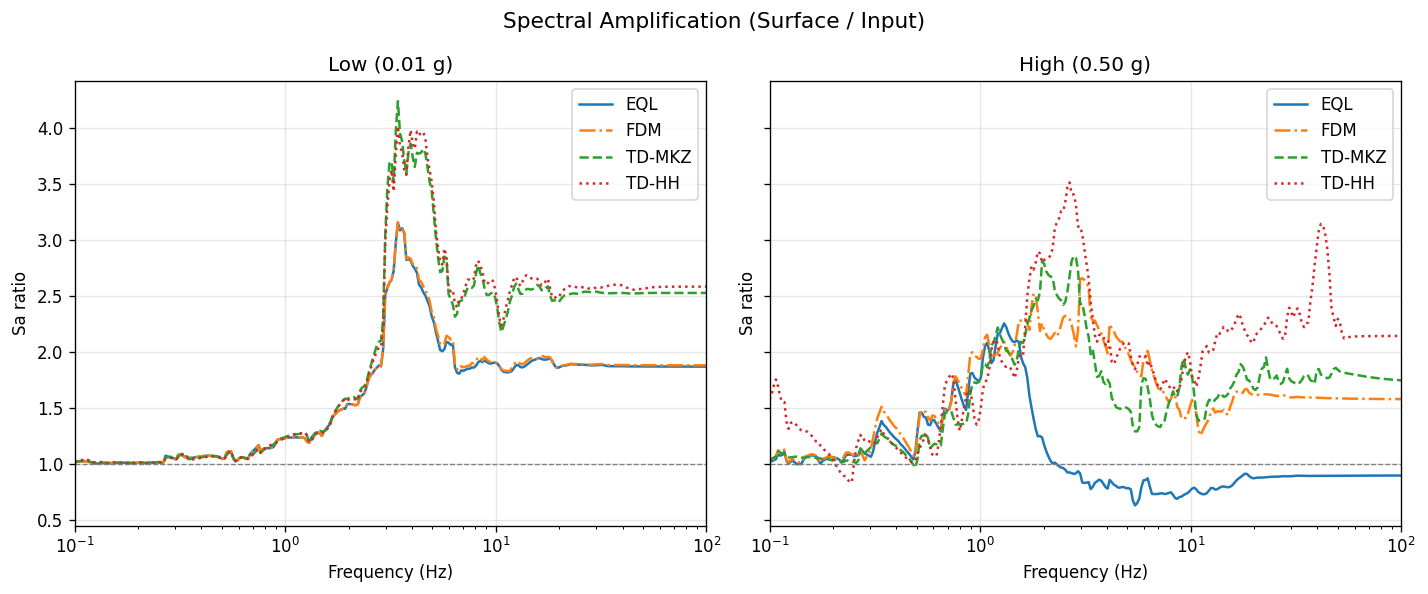

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, label, title in zip(axes, ["low", "high"], ["Low (0.01 g)", "High (0.50 g)"]):
    # All methods from OutputCollection
    ratio_output = all_outputs[label][1]  # ResponseSpectrumRatioOutput
    for name, refs, values in ratio_output.iter_results():
        ax.plot(refs, values, linestyles[name], color=colors[name], label=name, lw=1.5)

    ax.axhline(1, color="gray", lw=0.8, ls="--")
    ax.set(
        xscale="log",
        xlabel="Frequency (Hz)",
        ylabel="Sa ratio",
        title=title,
        xlim=(0.1, 100),
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Spectral Amplification (Surface / Input)", fontsize=13)
fig.tight_layout()

## 7. Maximum Strain Profiles

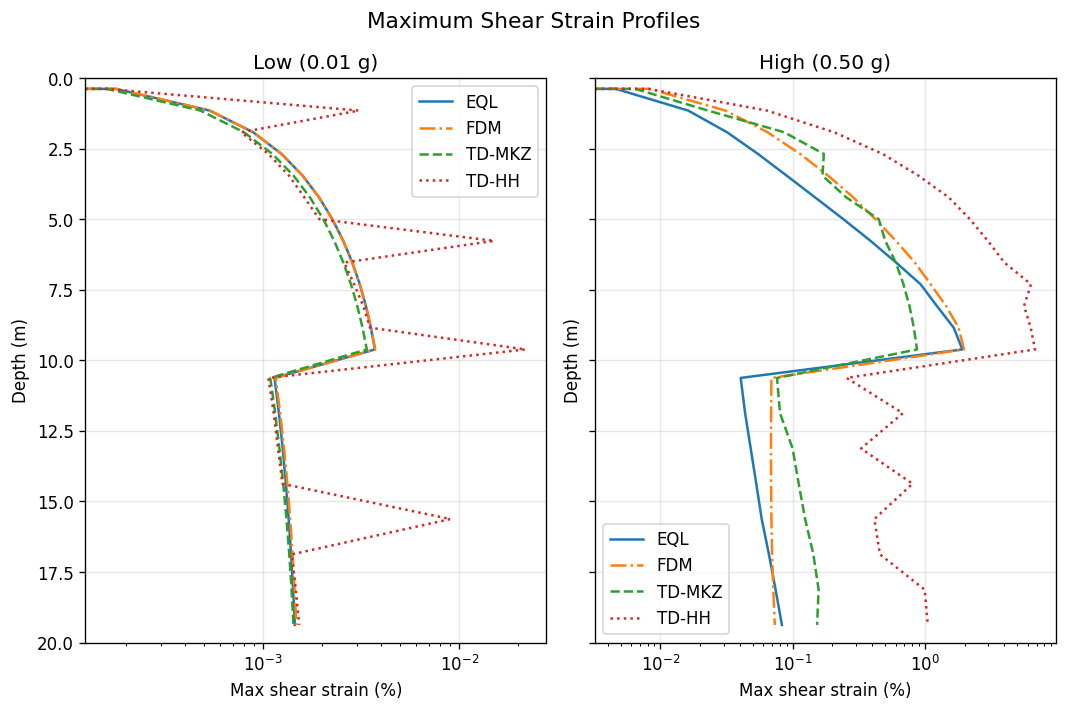

In [13]:
fig, axes = plt.subplots(
    1, 2, figsize=(9, 6), sharey=True, subplot_kw={"ylim": (20, 0)}
)

for ax, label, title in zip(axes, ["low", "high"], ["Low (0.01 g)", "High (0.50 g)"]):
    strain_output = all_outputs[label][2]  # MaxStrainProfile
    for name, depths, strains in strain_output.iter_results():
        ax.semilogx(
            strains * 100,
            depths,
            linestyles[name],
            color=colors[name],
            label=name,
            lw=1.5,
        )
    ax.set(xlabel="Max shear strain (%)", ylabel="Depth (m)", title=title)
    ax.legend()
    ax.grid(True, alpha=0.3)


fig.suptitle("Maximum Shear Strain Profiles", fontsize=13)
fig.tight_layout()

## 8. Surface Time Histories (TD methods only)

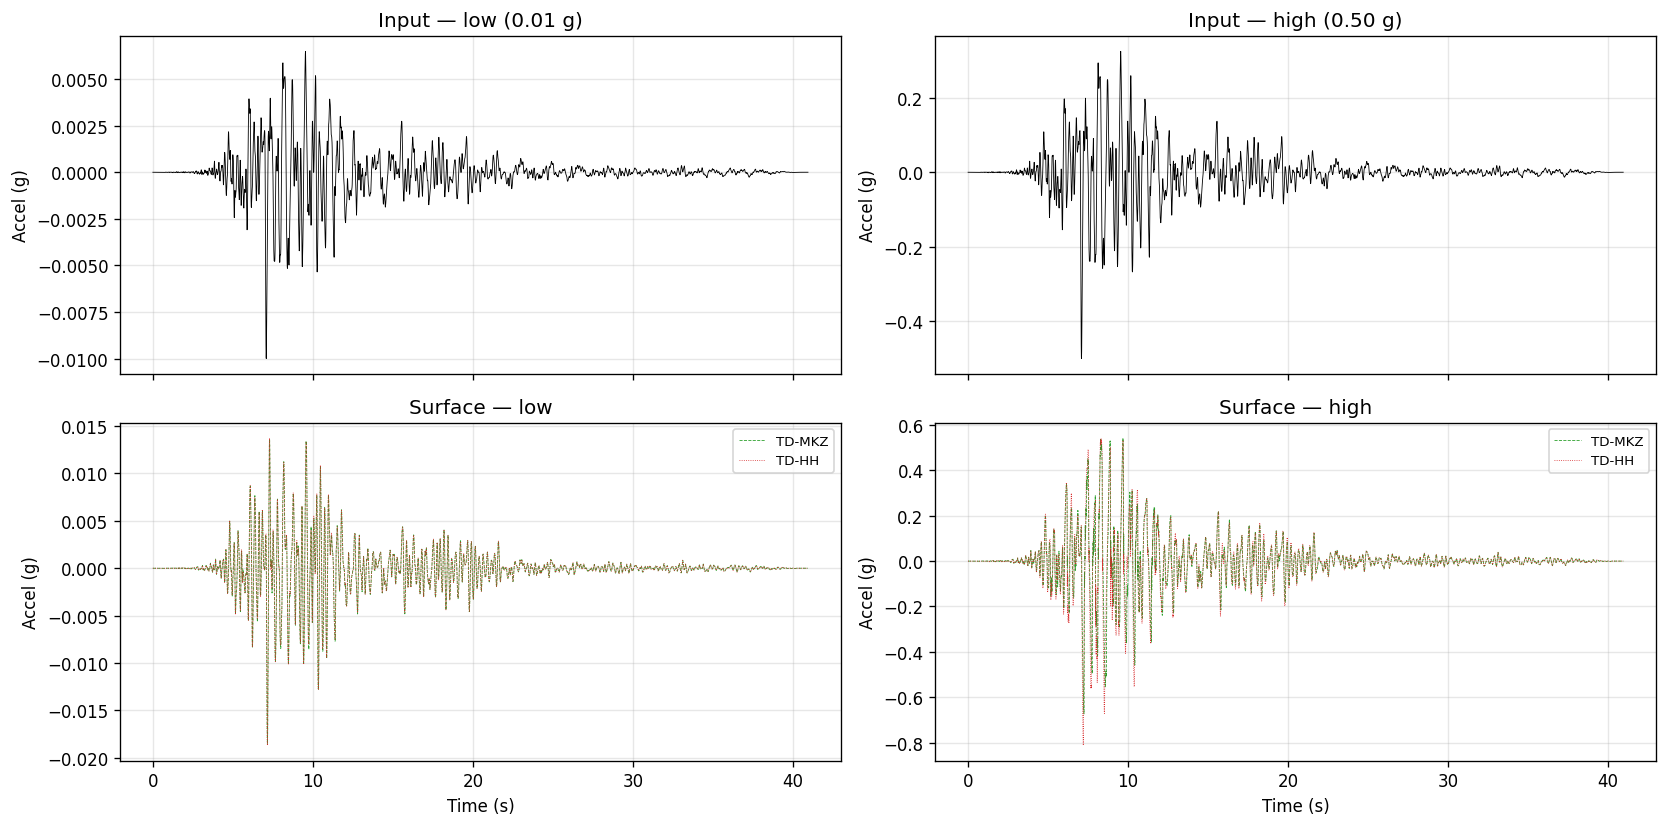

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex="col")

for col, (label, motion) in enumerate([("low", motion_low), ("high", motion_high)]):
    # Input motion
    axes[0, col].plot(motion.times, motion.accels, "k", lw=0.5)
    axes[0, col].set_title(f"Input — {label} ({motion.pga:.2f} g)")

    # Overlay surface responses from both TD methods
    loc_surf = profile.location("outcrop", index=0)
    for method in ["TD-MKZ", "TD-HH"]:
        calc = all_calcs[(label, method)]
        times = calc.times
        accels = calc.accel_ts(loc_surf)
        axes[1, col].plot(
            times,
            accels,
            lw=0.5,
            color=colors[method],
            ls=linestyles[method],
            label=method,
        )
    axes[1, col].set_title(f"Surface — {label}")
    axes[1, col].legend(fontsize=8)

for ax in axes.flat:
    ax.set_ylabel("Accel (g)")
    ax.grid(True, alpha=0.3)
for ax in axes[1]:
    ax.set_xlabel("Time (s)")

fig.tight_layout()

## 9. Summary Table

In [15]:
print(
    f"{'Method':<10} {'Low PGA out (g)':>17} {'High PGA out (g)':>18} {'Ratio H/L':>12}"
)
print("-" * 62)

for name in ["EQL", "FDM", "TD-MKZ", "TD-HH"]:
    lo = all_outputs["low"][0]  # ResponseSpectrumOutput
    hi = all_outputs["high"][0]
    pga_lo = max(
        v for n, r, vals in lo.iter_results() if n == name for v in [np.max(vals)]
    )
    pga_hi = max(
        v for n, r, vals in hi.iter_results() if n == name for v in [np.max(vals)]
    )

    ratio = pga_hi / pga_lo if pga_lo > 0 else float("nan")
    print(f"{name:<10} {pga_lo:>17.4f} {pga_hi:>18.4f} {ratio:>12.1f}")

Method       Low PGA out (g)   High PGA out (g)    Ratio H/L
--------------------------------------------------------------
EQL                   0.0672             2.3111         34.4
FDM                   0.0673             3.2743         48.6
TD-MKZ                0.0603             2.9327         48.6
TD-HH                 0.0604             3.3578         55.6


## 10. Save Results to tests/data/comparison/

Everything needed for regression tests is saved here: profile parameters,
motion time series, response spectra, strain profiles, and surface time histories.

In [16]:
OUT_DIR = pathlib.Path("../tests/data/comparison")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Profile metadata (layer parameters as plain arrays) ----
profile_data = {
    "thicknesses": np.array([10.0, 10.0, 0.0]),
    "shear_vels": np.array([200.0, 350.0, 700.0]),
    "unit_wts": np.array([18.0, 19.0, 24.0]),
    "plas_indexes": np.array([20.0, 15.0, 0.0]),
    "stress_means": np.array([50.0, 150.0, 0.0]),
    "ocrs": np.array([1.0, 1.0, 1.0]),
    "dampings": np.array([0.05, 0.05, 0.01]),  # approximate small-strain
}
np.savez(OUT_DIR / "profile.npz", **profile_data)

# ---- Input motions ----
for label, motion in [("low", motion_low), ("high", motion_high)]:
    np.savez(
        OUT_DIR / f"motion_{label}.npz",
        times=motion.times,
        accels=motion.accels,
        dt=np.array([motion.time_step]),
        pga=np.array([motion.pga]),
    )

# ---- Surface time histories (TD methods) ----
loc_surf = profile.location("outcrop", index=0)
for label in ["low", "high"]:
    for name in ["TD-MKZ", "TD-HH"]:
        calc = all_calcs[(label, name)]
        times = calc.times
        accels = calc.accel_ts(loc_surf)
        fname = f"surface_ts_{label}_{name.replace('-', '_').lower()}.npz"
        np.savez(OUT_DIR / fname, times=times, accels=accels)

# ---- Response spectra ----
for label in ["low", "high"]:
    rs_output = all_outputs[label][0]
    rs_data = {"freqs": rs_output.refs}
    for name, refs, values in rs_output.iter_results():
        rs_data[name.replace("-", "_")] = values
    np.savez(OUT_DIR / f"response_spectra_{label}.npz", **rs_data)

# ---- Spectral ratios ----
for label in ["low", "high"]:
    ratio_output = all_outputs[label][1]
    ratio_data = {"freqs": ratio_output.refs}
    for name, refs, values in ratio_output.iter_results():
        ratio_data[name.replace("-", "_")] = values
    np.savez(OUT_DIR / f"spectral_ratios_{label}.npz", **ratio_data)

# ---- Max strain profiles ----
for label in ["low", "high"]:
    strain_output = all_outputs[label][2]
    strain_data = {}
    for name, depths, strains in strain_output.iter_results():
        if "depths" not in strain_data:
            strain_data["depths"] = depths
        strain_data[name.replace("-", "_")] = strains
    np.savez(OUT_DIR / f"max_strains_{label}.npz", **strain_data)

print("Saved files:")
for f in sorted(OUT_DIR.glob("*.npz")):
    print(f"  {f.name}")

Saved files:
  max_strains_high.npz
  max_strains_low.npz
  motion_high.npz
  motion_low.npz
  profile.npz
  response_spectra_high.npz
  response_spectra_low.npz
  spectral_ratios_high.npz
  spectral_ratios_low.npz
  surface_ts_high_td_hh.npz
  surface_ts_high_td_mkz.npz
  surface_ts_low_td_hh.npz
  surface_ts_low_td_mkz.npz
